In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from tools.preprocessing_script import get_real_data_split
from tools.simulated_data import generate_dataset
from tools.utils import FMRIDataset

In [28]:
%reload_ext autoreload
%autoreload 2

# Regimes comparison

In [2]:
regime_medium = {
    'onset_lambda': 1/40,
    'duration_interval': (10, 40),
    'amplitude_interval': (-1, 1)
}

regime_hard = {
    'onset_lambda': 1/5,
    'duration_interval': (5, 30),
    'amplitude_interval': (-1, 1)
}

regime_new = {
    'onset_lambda': 1/20,
    'duration_interval': (10, 40),
    'amplitude_interval': (-1, 1)
}

100%|██████████████████████████████████████| 100/100 [00:00<00:00, 17404.47it/s]


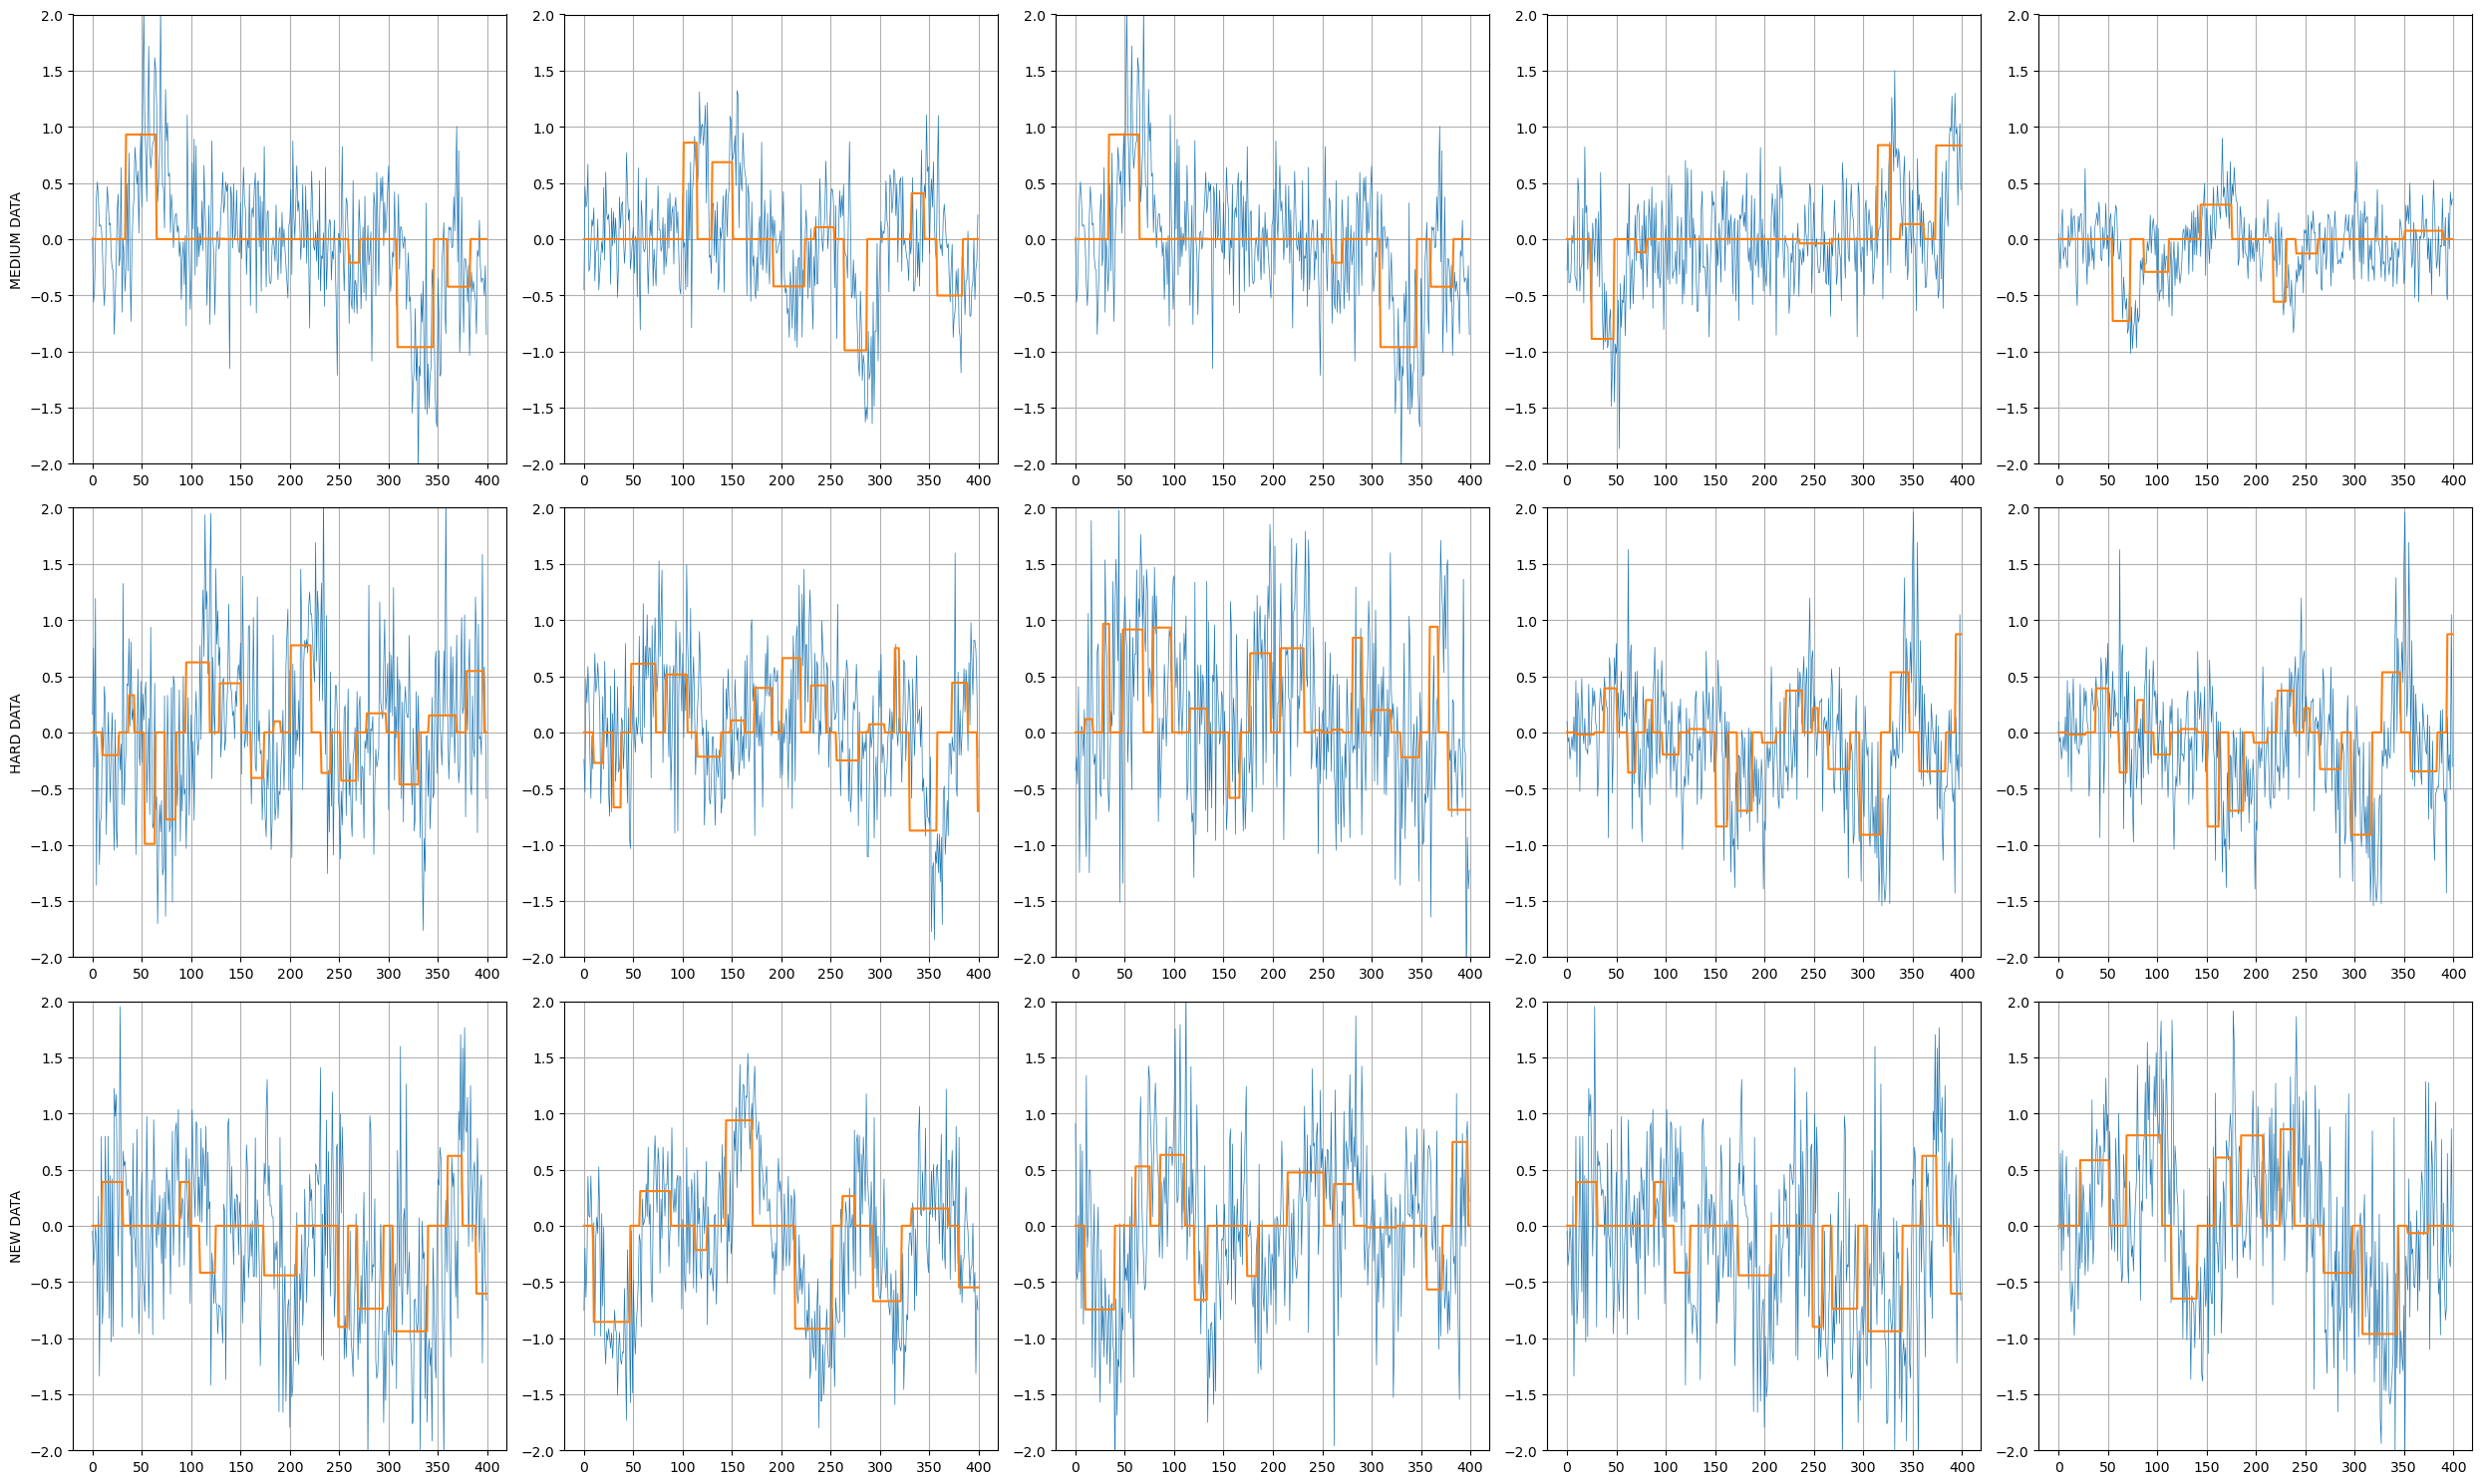

In [8]:
# Quick data visualisation
n_points, n_voxels, snr_range = 400, 300, (-5, 3)

y, convolved_signals, X = generate_dataset(
    n_points, n_voxels, [regime_medium, regime_hard, regime_new], snr_range, min_onset_interval=10
)

f, ax = plt.subplots(3, 5, figsize=(25, 15))
for i in range(5):
    
    v_easy = np.random.randint(0, 10)
    ax[0, i].plot(X[v_easy], label='input', linewidth=0.5)
    #ax[0, i].plot(convolved_signals[v_easy], label='convolved signal')
    ax[0, i].plot(y[v_easy], label='target')
    
    v_medium = np.random.randint(100, 110)
    ax[1, i].plot(X[v_medium], label='input', linewidth=0.5)
    #ax[1, i].plot(convolved_signals[v_medium], label='convolved signal')
    ax[1, i].plot(y[v_medium], label='target')
    
    v_hard = np.random.randint(200, 210)
    ax[2, i].plot(X[v_hard], label='input', linewidth=0.5)
    #ax[2, i].plot(convolved_signals[v_hard], label='convolved signal')
    ax[2, i].plot(y[v_hard], label='target')

for a in ax.flatten(): a.set_ylim([-2, 2]), a.grid()

ax[0, 0].set_ylabel('MEDIUM DATA')
ax[1, 0].set_ylabel('HARD DATA')
ax[2, 0].set_ylabel('NEW DATA')
f.tight_layout()

# Comparison with real data

In [2]:
# Get real data
dataset_motor = get_real_data_split('motor')
real_data_test = dataset_motor['test']

Preprocessing train set with augmentation set to True:


100%|███████████████████████████████████████████| 60/60 [00:14<00:00,  4.23it/s]


Preprocessing validation set:


100%|███████████████████████████████████████████| 20/20 [00:04<00:00,  4.76it/s]


Preprocessing test set:


100%|███████████████████████████████████████████| 20/20 [00:08<00:00,  2.48it/s]


In [ ]:
# Generate simulated data
regime_bob = {
    'onset_lambda': 1/2,
    'duration_interval': (10, 40),
    'amplitude_interval': (-2.5, 2.5)
}
n_points, n_voxels, snr_range = 284, 300, (-1, 6)
y, _, X = generate_dataset(
    n_points, n_voxels, regime_bob, snr_range, min_onset_interval=10
)
sim_data_test = FMRIDataset(X, y)

NameError: name 'generate_dataset' is not defined

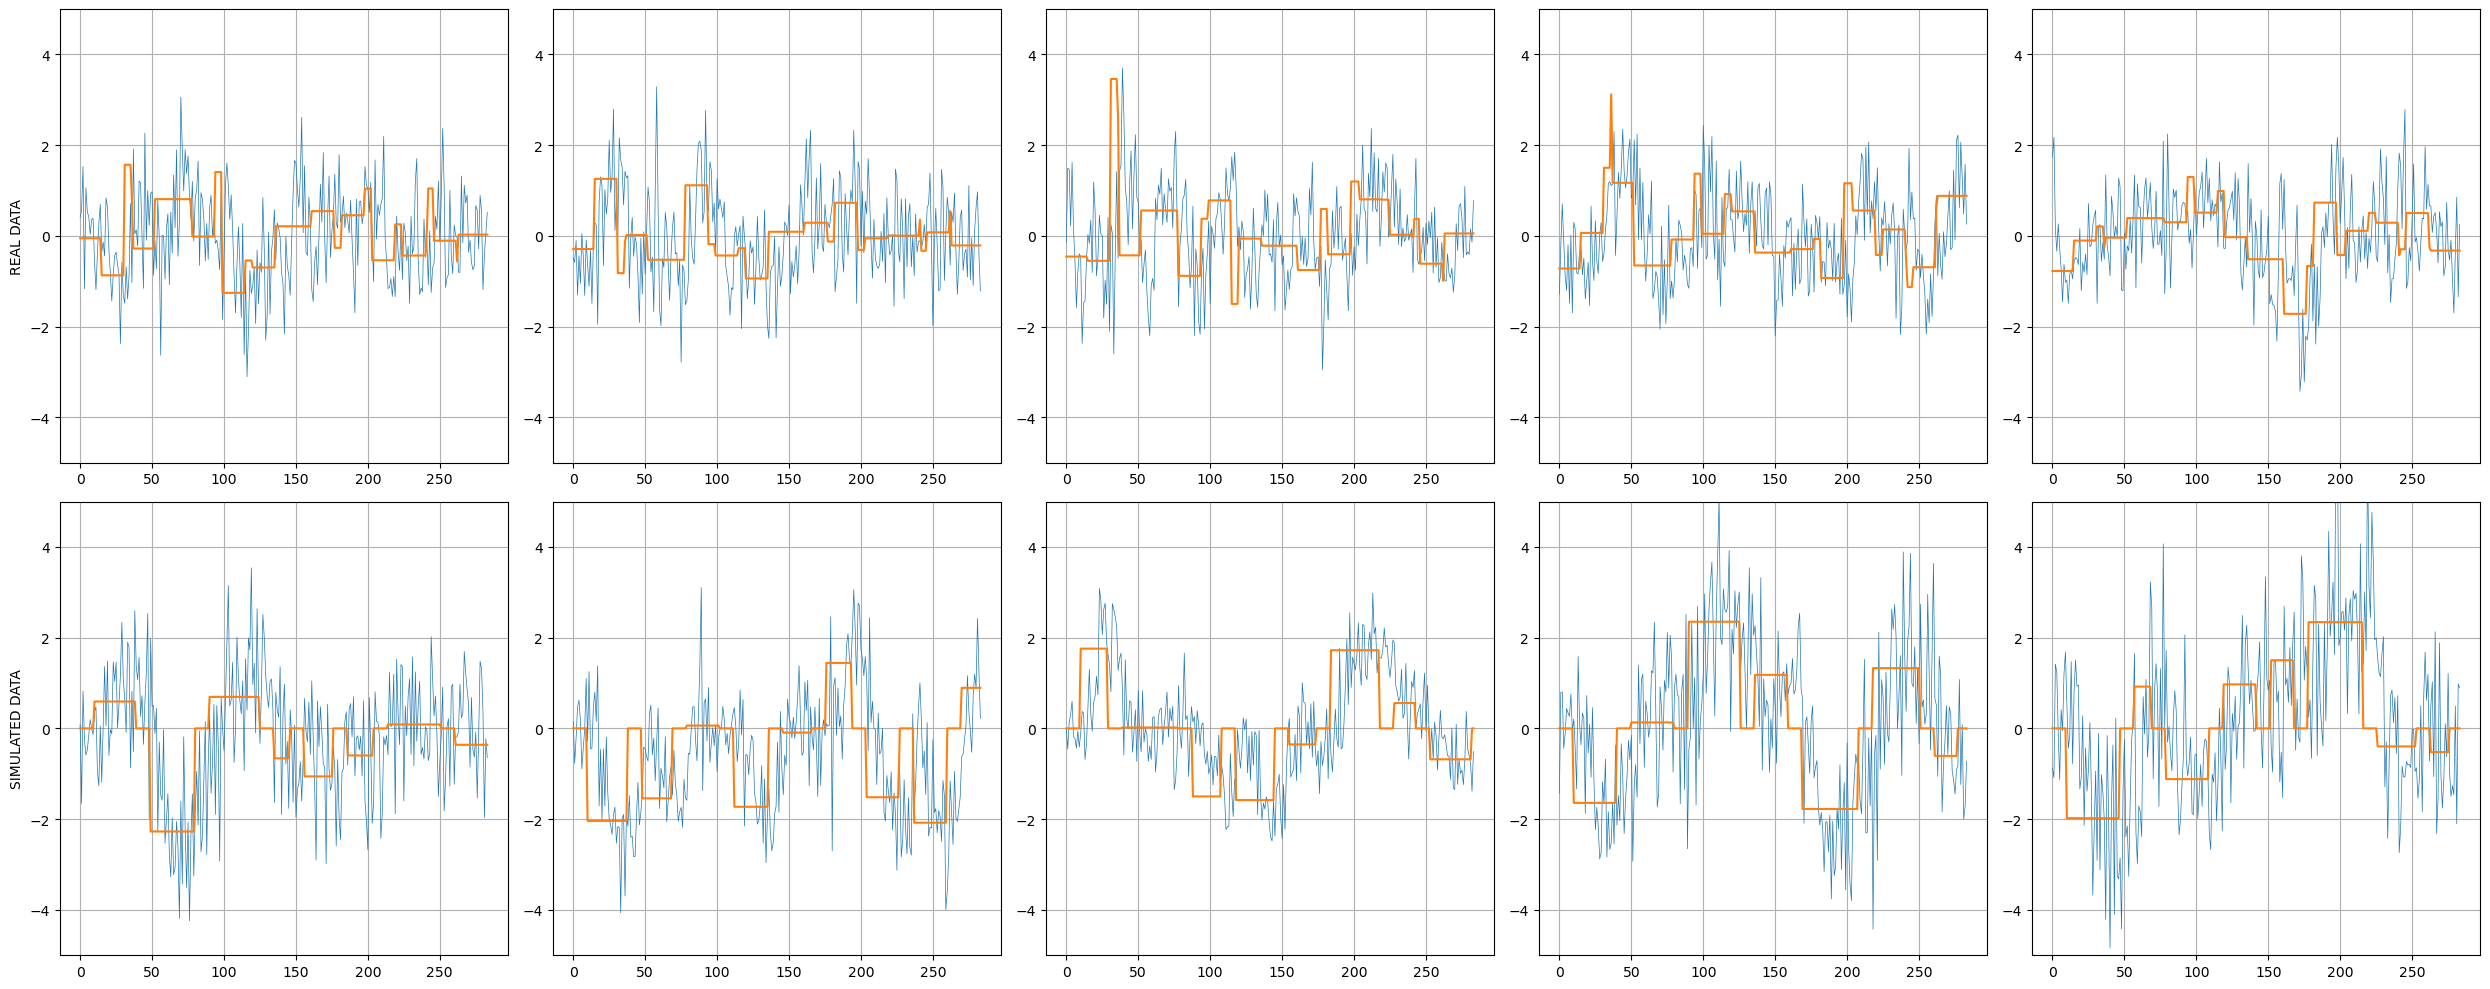

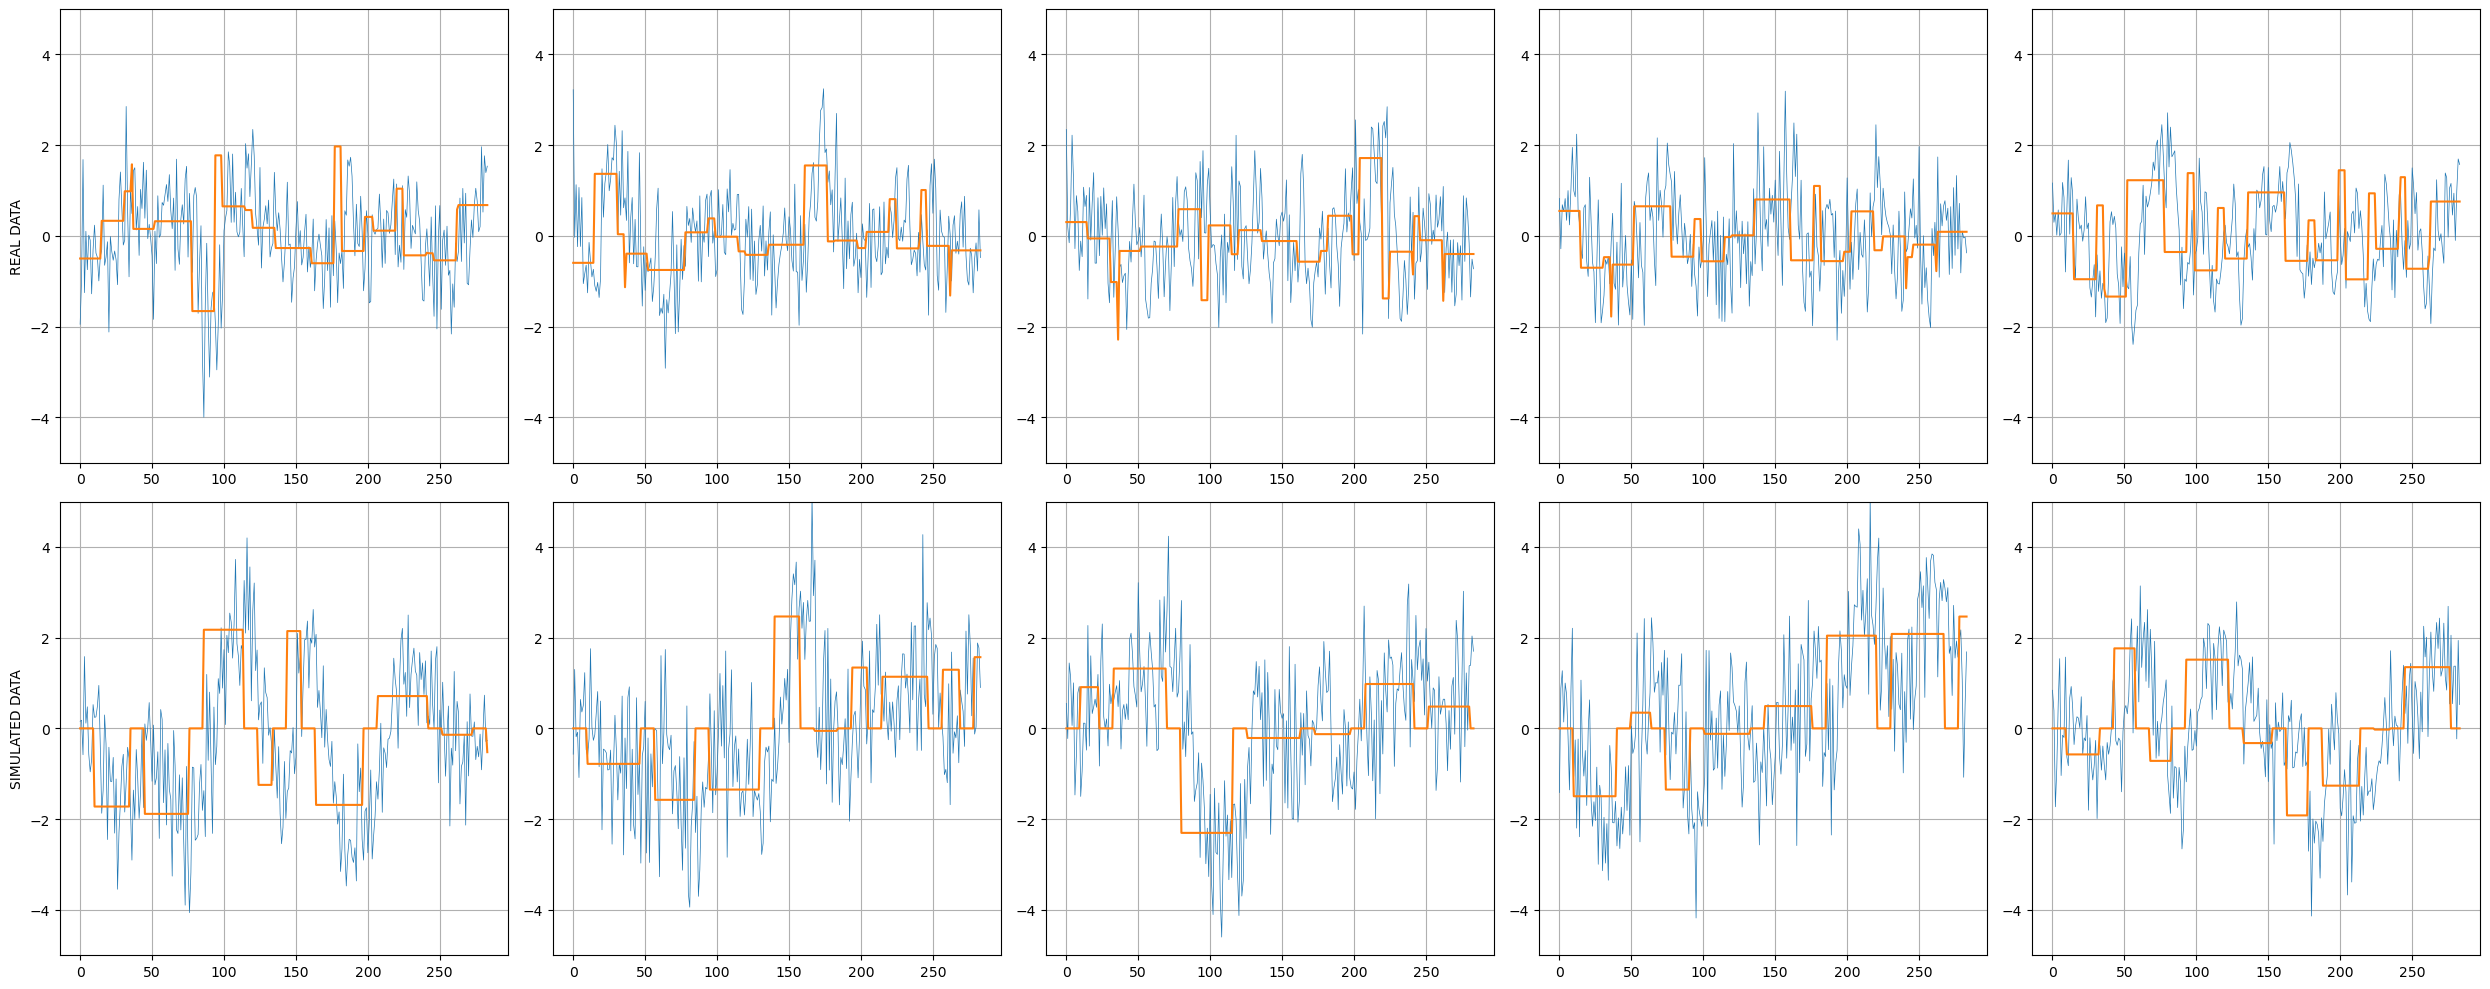

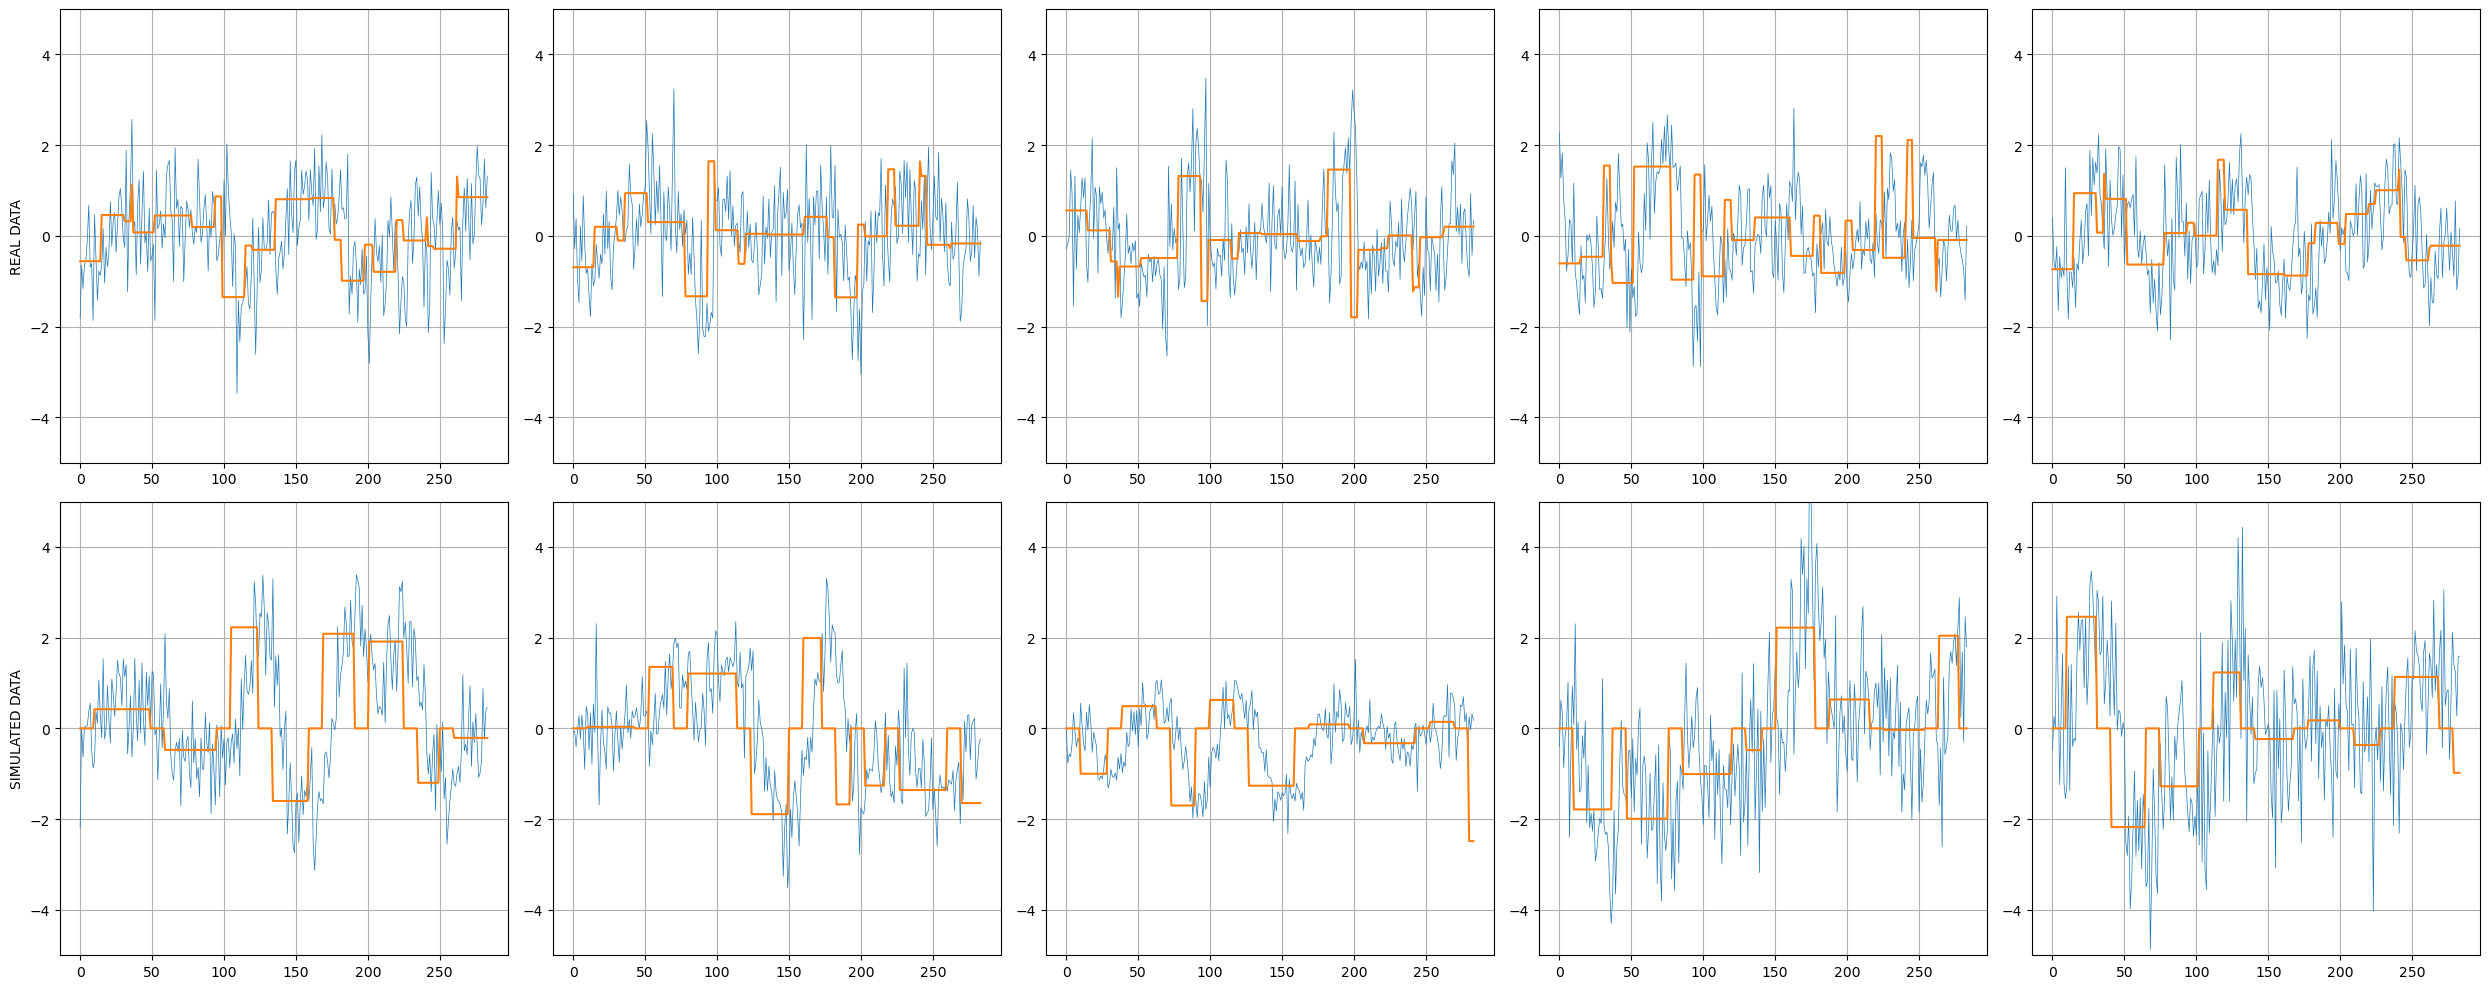

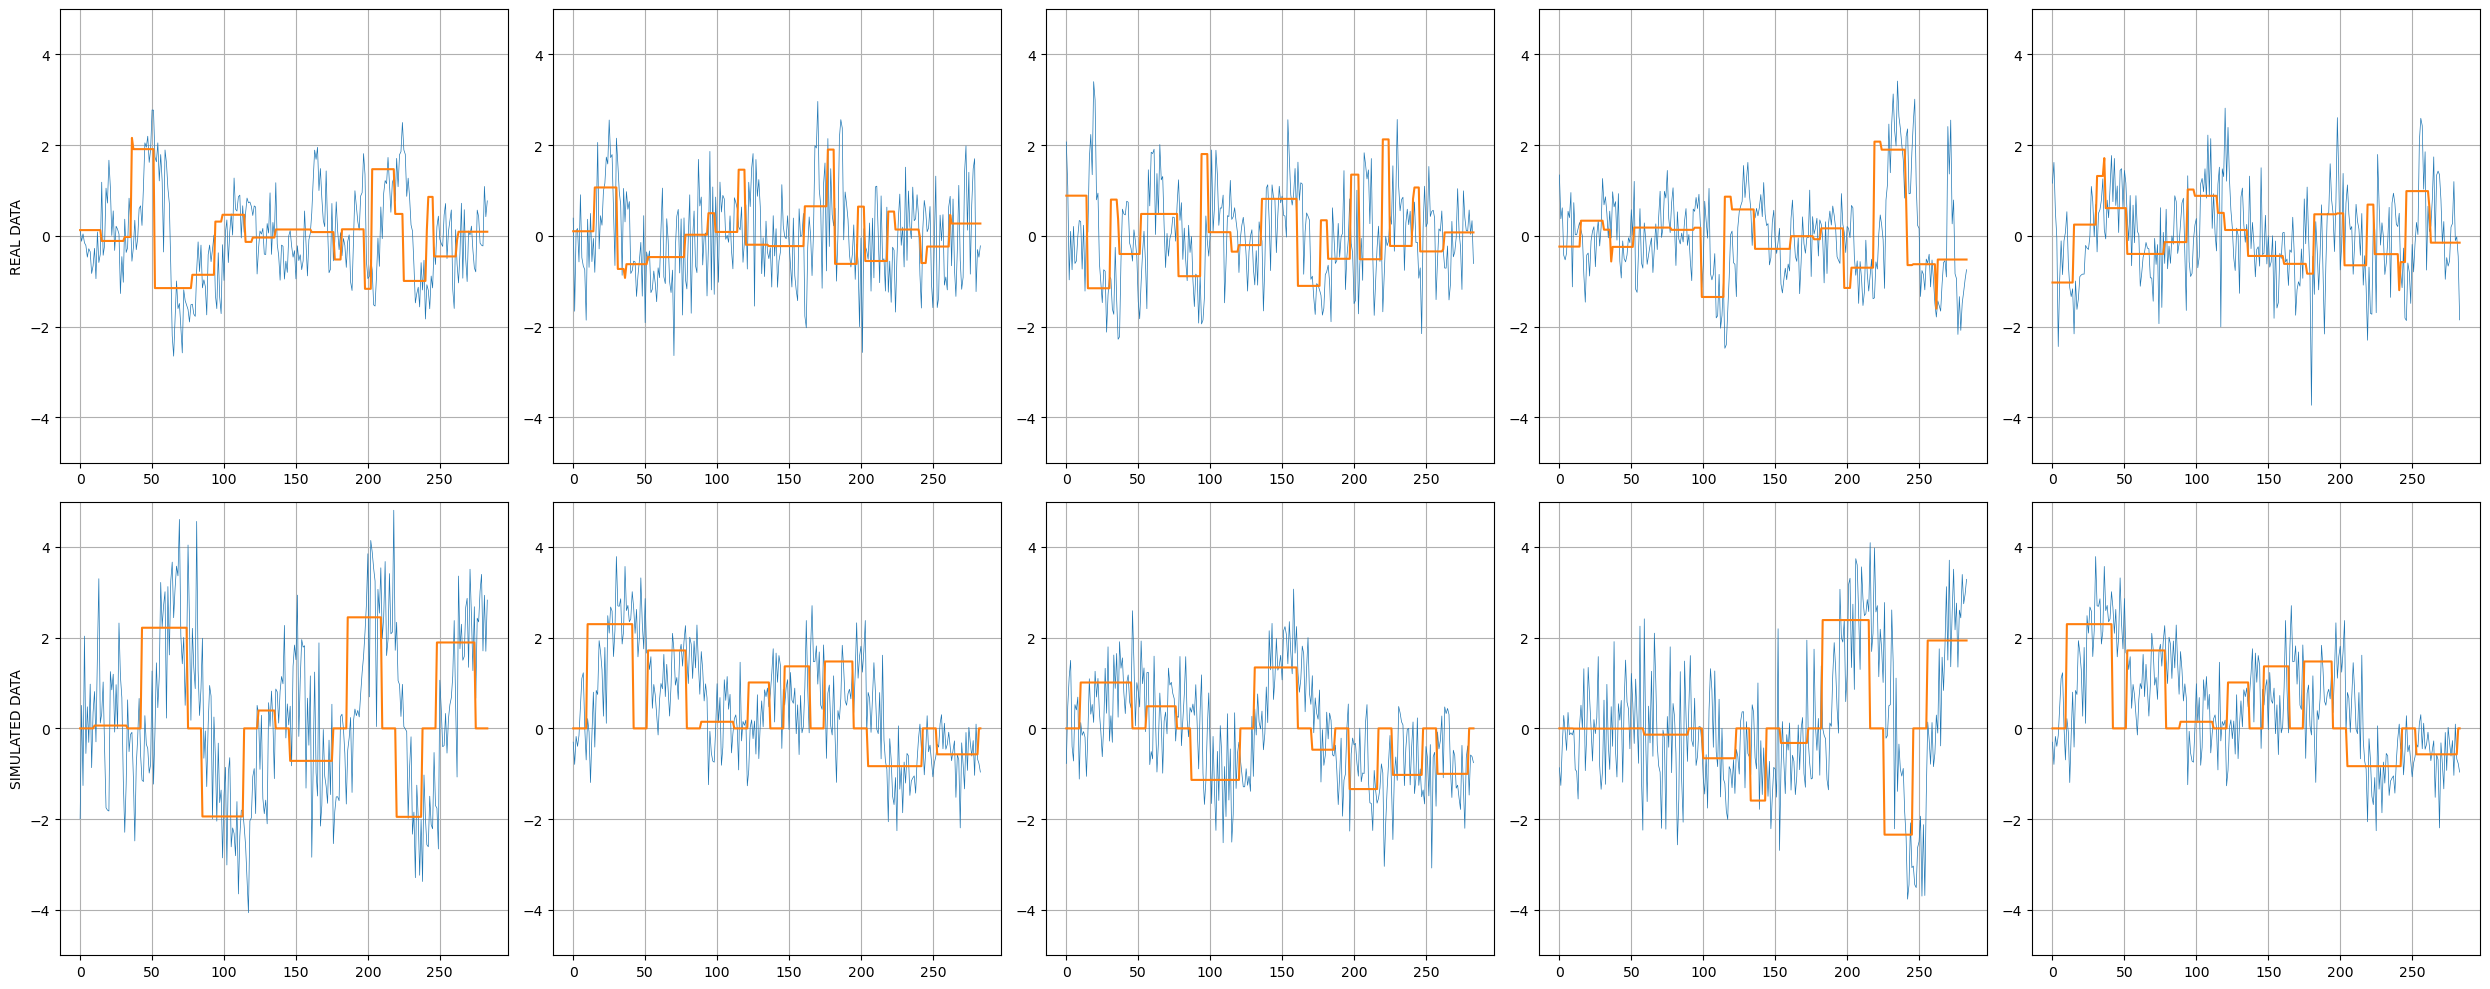

In [5]:
for _ in range(4):  
    f, ax = plt.subplots(2, 5, figsize=(25, 10))
    for i in range(5):
        
        v_real = np.random.randint(0, len(real_data_test))
        X_real, y_real = real_data_test[v_real][0], real_data_test[v_real][1]
        ax[0, i].plot(X_real, label='input', linewidth=0.5)
        ax[0, i].plot(y_real, label='target')
        
        v_sim = np.random.randint(0, len(sim_data_test))
        X_sim, y_sim = sim_data_test[v_sim][0], sim_data_test[v_sim][1]
        ax[1, i].plot(X_sim, label='input', linewidth=0.5)
        ax[1, i].plot(y_sim, label='target')

    for a in ax.flatten(): a.set_ylim([-5, 5]), a.grid()

    ax[0, 0].set_ylabel('REAL DATA')
    ax[1, 0].set_ylabel('SIMULATED DATA')
    f.tight_layout()

# Statistical comparison of simulated and real data

In [5]:
real_test_dataset = get_real_data_split('motor')['test']

Preprocessing train set with augmentation set to True:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [01:33<00:00,  1.56s/it]


Preprocessing validation set:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:19<00:00,  1.04it/s]


Preprocessing test set:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.14it/s]


In [8]:
# Generate simulated data
regime_bob = {
    'duration': (23, 10),
    'amplitude': (0, 0.65),
    'snr': (0.5, 3),
    'min_onset_interval': 10
}
n_points, n_voxels = 283, 1000
y, convolved, X = generate_dataset(
    n_points, n_voxels, regime_bob, method='random'
)
sim_data_test = FMRIDataset(X, y)

# max_ratio_sim = torch.max(torch.abs(sim_data_test.y), dim=1)[0] / torch.max(torch.abs(sim_data_test.X), dim=1)[0]
# max_ratio_real = torch.max(torch.abs(real_test_dataset.y), dim=1)[0] / torch.max(torch.abs(real_test_dataset.X), dim=1)[0]

# vp1 = plt.violinplot(max_ratio_sim, positions=[1], showmeans=True)
# vp2 = plt.violinplot(max_ratio_real, positions=[2], showmeans=True)
# plt.legend([vp1['bodies'][0],vp2['bodies'][0]], ['simulated', 'real'], loc=2)
# plt.title('Ratio: max(u) / max(BOLD) for all samples')
# plt.grid()
# plt.show(9)

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 2253.77it/s]


Convolving signals with random HRFs.


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 4682.43it/s]


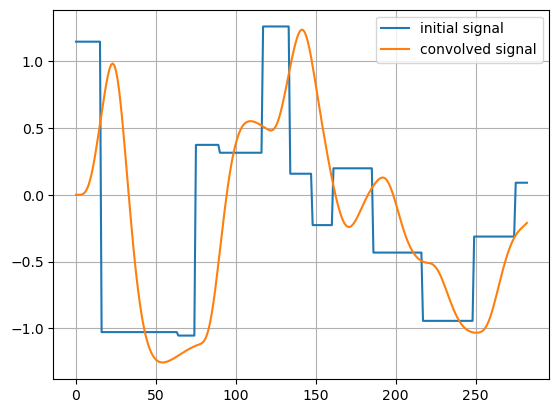

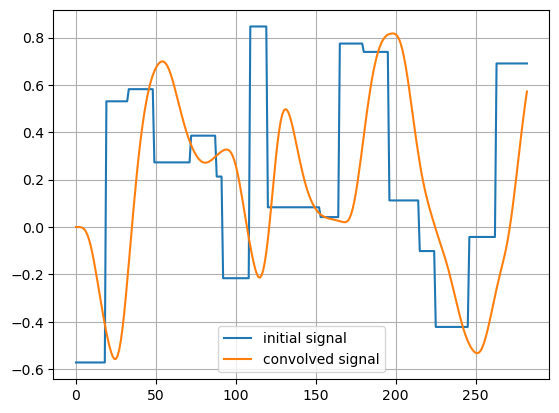

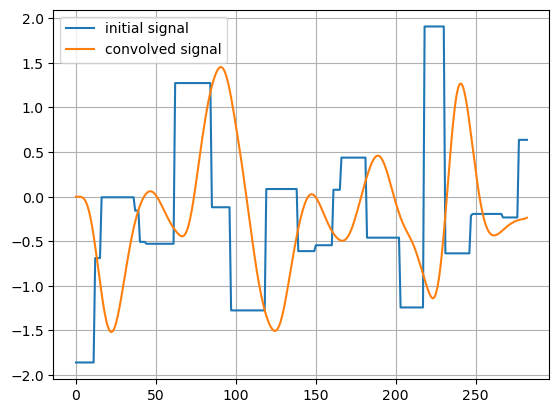

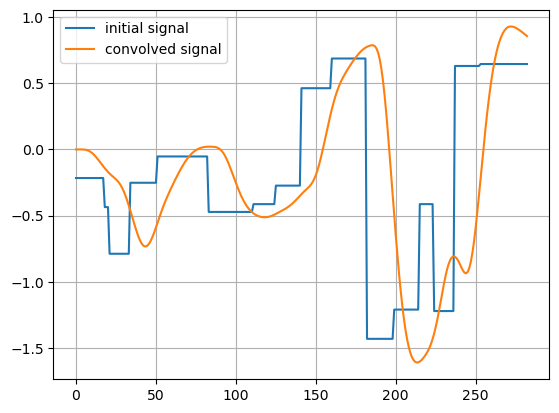

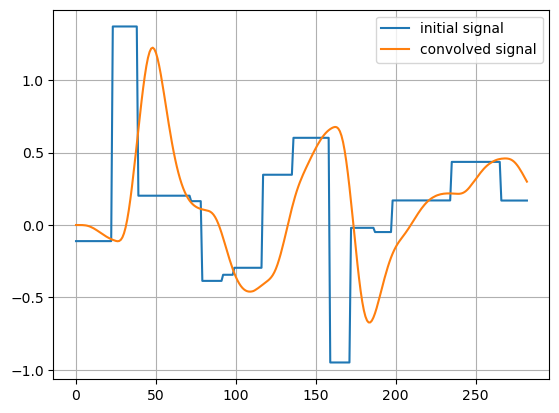

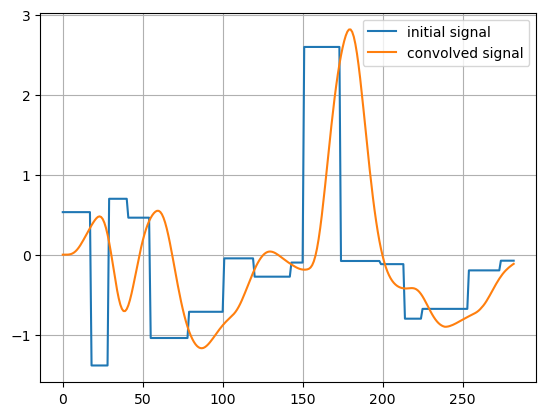

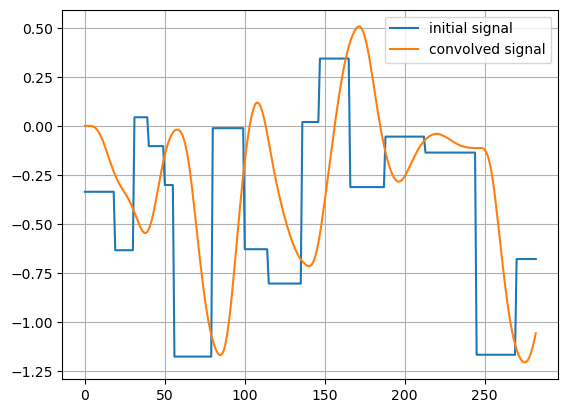

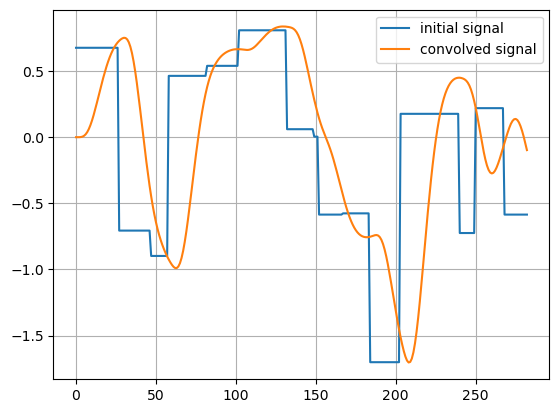

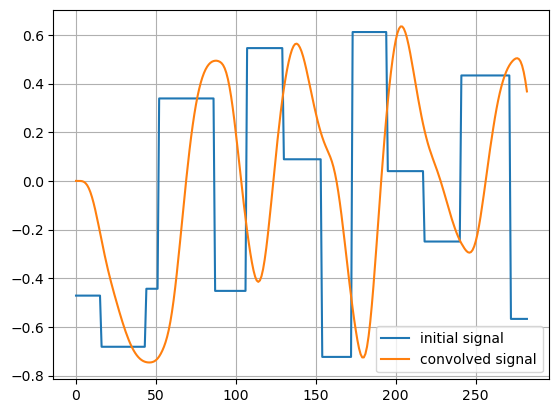

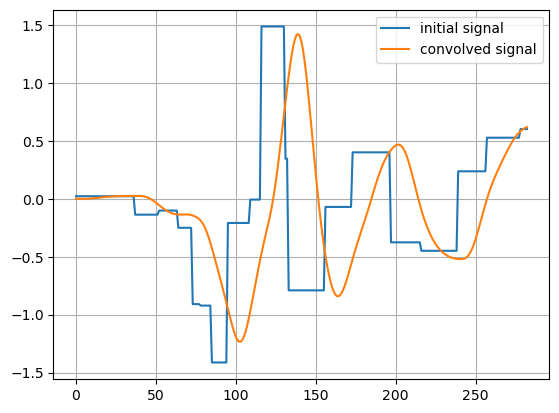

In [9]:
voxels = np.random.randint(0, 1000, size=(10,))
for v in voxels:
    plt.figure()
    plt.plot(y[v], label='initial signal')
    plt.plot(convolved[v], label='convolved signal')
    plt.legend()
    plt.grid()

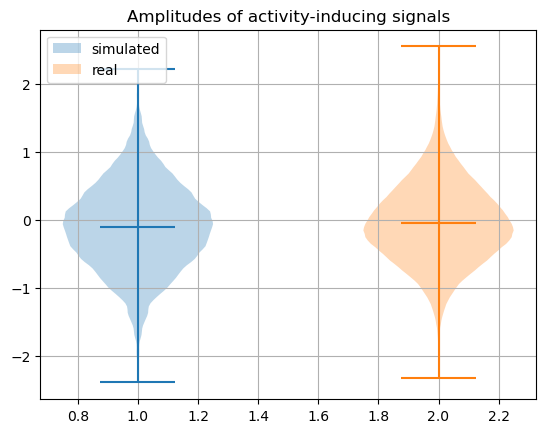

In [61]:
vp1 = plt.violinplot(sim_data_test.y.flatten(), positions=[1], showmeans=True)
vp2 = plt.violinplot(real_test_dataset.y.flatten(), positions=[2], showmeans=True)
plt.grid()
plt.legend([vp1['bodies'][0],vp2['bodies'][0]], ['simulated', 'real'], loc=2)
plt.title('Amplitudes of activity-inducing signals')
plt.show()

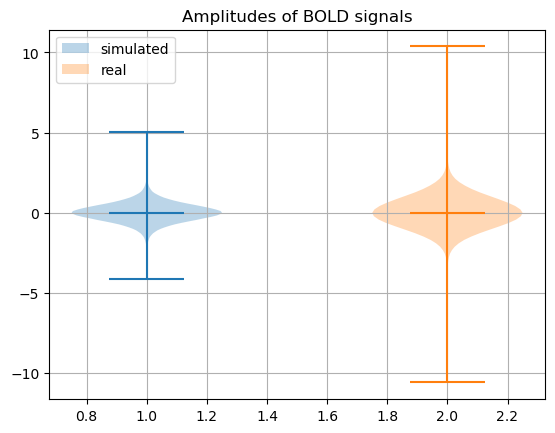

In [102]:
vp1 = plt.violinplot(sim_data_test.X.flatten(), positions=[1], showmeans=True)
vp2 = plt.violinplot(real_test_dataset.X.flatten(), positions=[2], showmeans=True)
plt.legend([vp1['bodies'][0],vp2['bodies'][0]], ['simulated', 'real'], loc=2)
plt.title('Amplitudes of BOLD signals')
plt.grid()
plt.show()

# Final simulated data

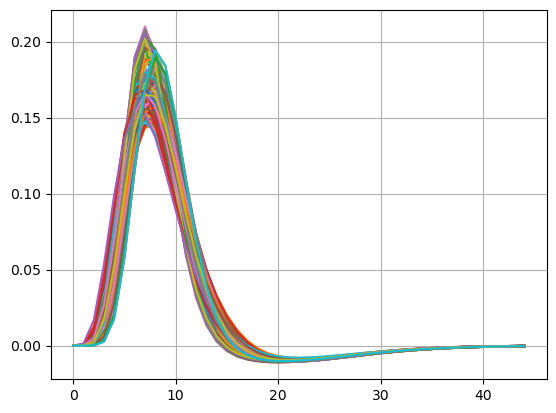

In [67]:
from nilearn.glm.first_level import spm_hrf, glover_hrf
from nipy.modalities.fmri.hrf import spmt, spm_hrf_compat

tr = .72

hrf_signal_glover = glover_hrf(tr, oversampling=2)
spm_hrf = spm_hrf(tr, oversampling=1, time_length=32.0, onset=0.) 

t = np.arange(0, 32, tr)

for i in range(100):
    hrf = spm_hrf_compat(
        t,
        peak_delay=np.random.uniform(5.5, 6.5),
        under_delay=np.random.uniform(15.5, 16.5),
        peak_disp=np.random.uniform(0.5, 1),
        under_disp=np.random.uniform(1.5, 1.8),
        p_u_ratio=max(6.5, np.random.normal(6, 0.5)),
        normalize=True
    )
    plt.plot(hrf)
# plt.plot(spm_hrf, linewidth=5, c='r')
plt.grid()

In [4]:
sim_data = torch.load('datasets/simulated_data_alice_300m.pt')['test']

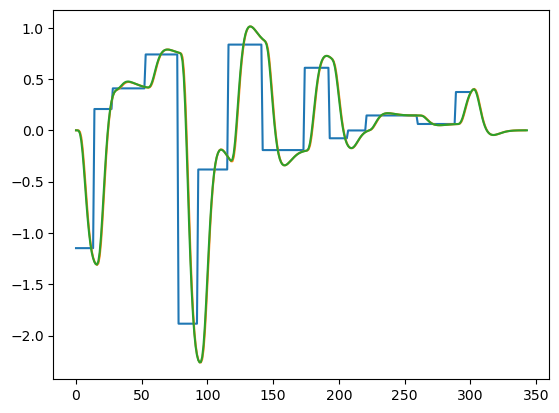

In [26]:
from scipy.signal import convolve

spm_hrf_1 = spm_hrf(tr, oversampling=1, time_length=32.0, onset=0.) 
spm_hrf_2 = spm_hrf(tr, oversampling=2, time_length=32.0, onset=0.)[0:]

u = sim_data[10][1]

plt.plot(u)
plt.plot(convolve(u, spm_hrf_1))
plt.plot(convolve(u, 2*spm_hrf_2[::2]))

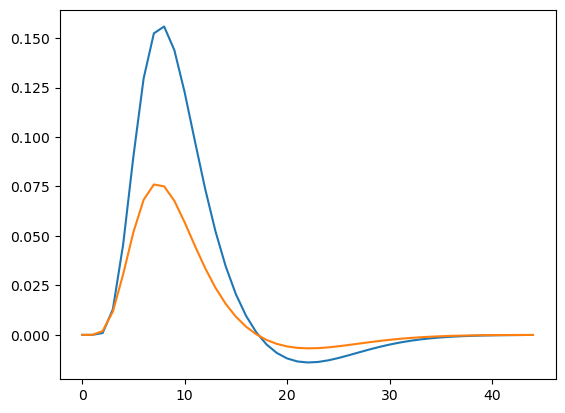

In [24]:
spm_hrf_1.shape, spm_hrf_2.shape
plt.plot(spm_hrf_1)
plt.plot(spm_hrf_2[::2])

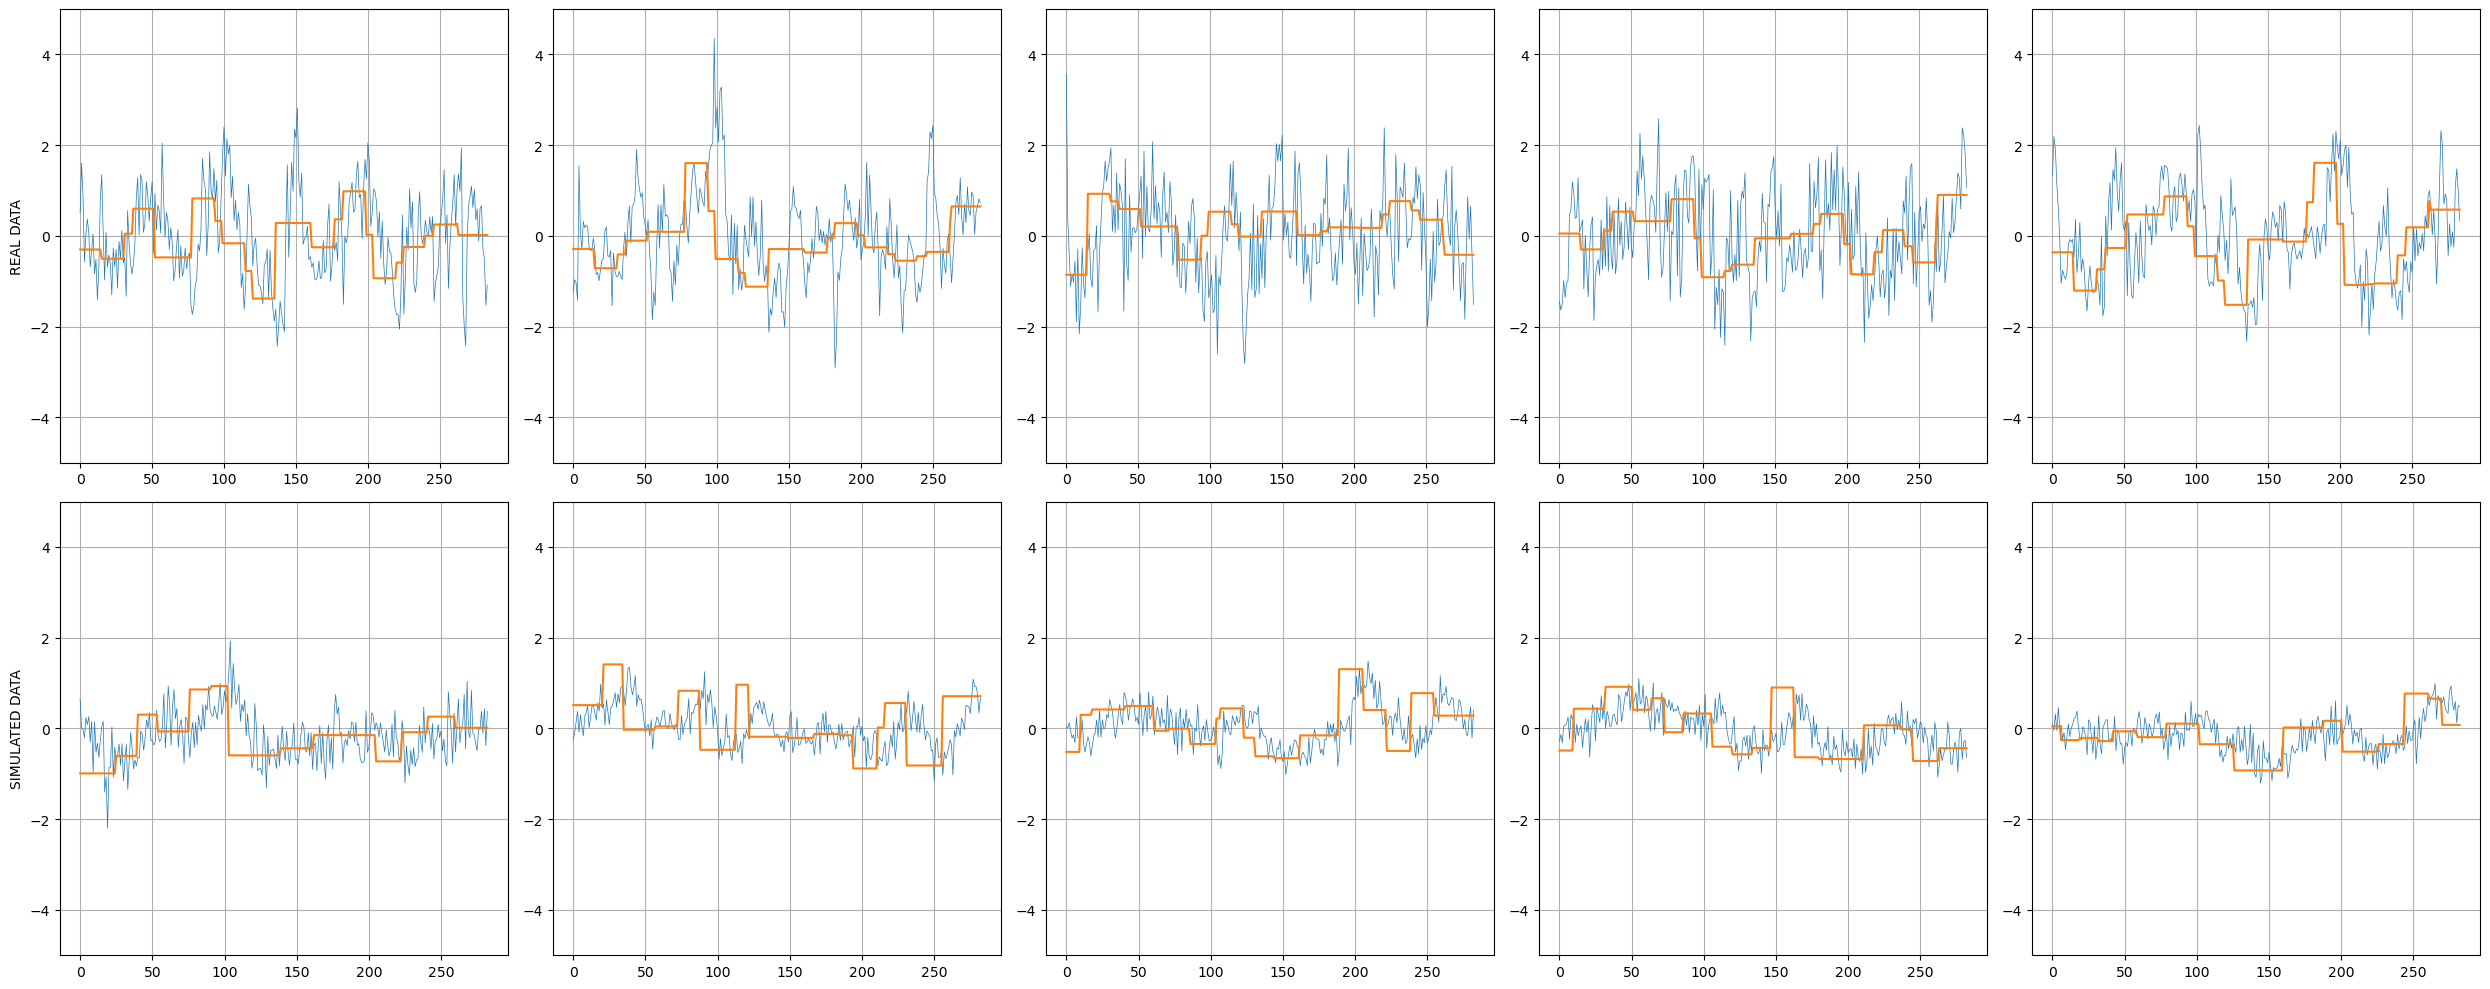

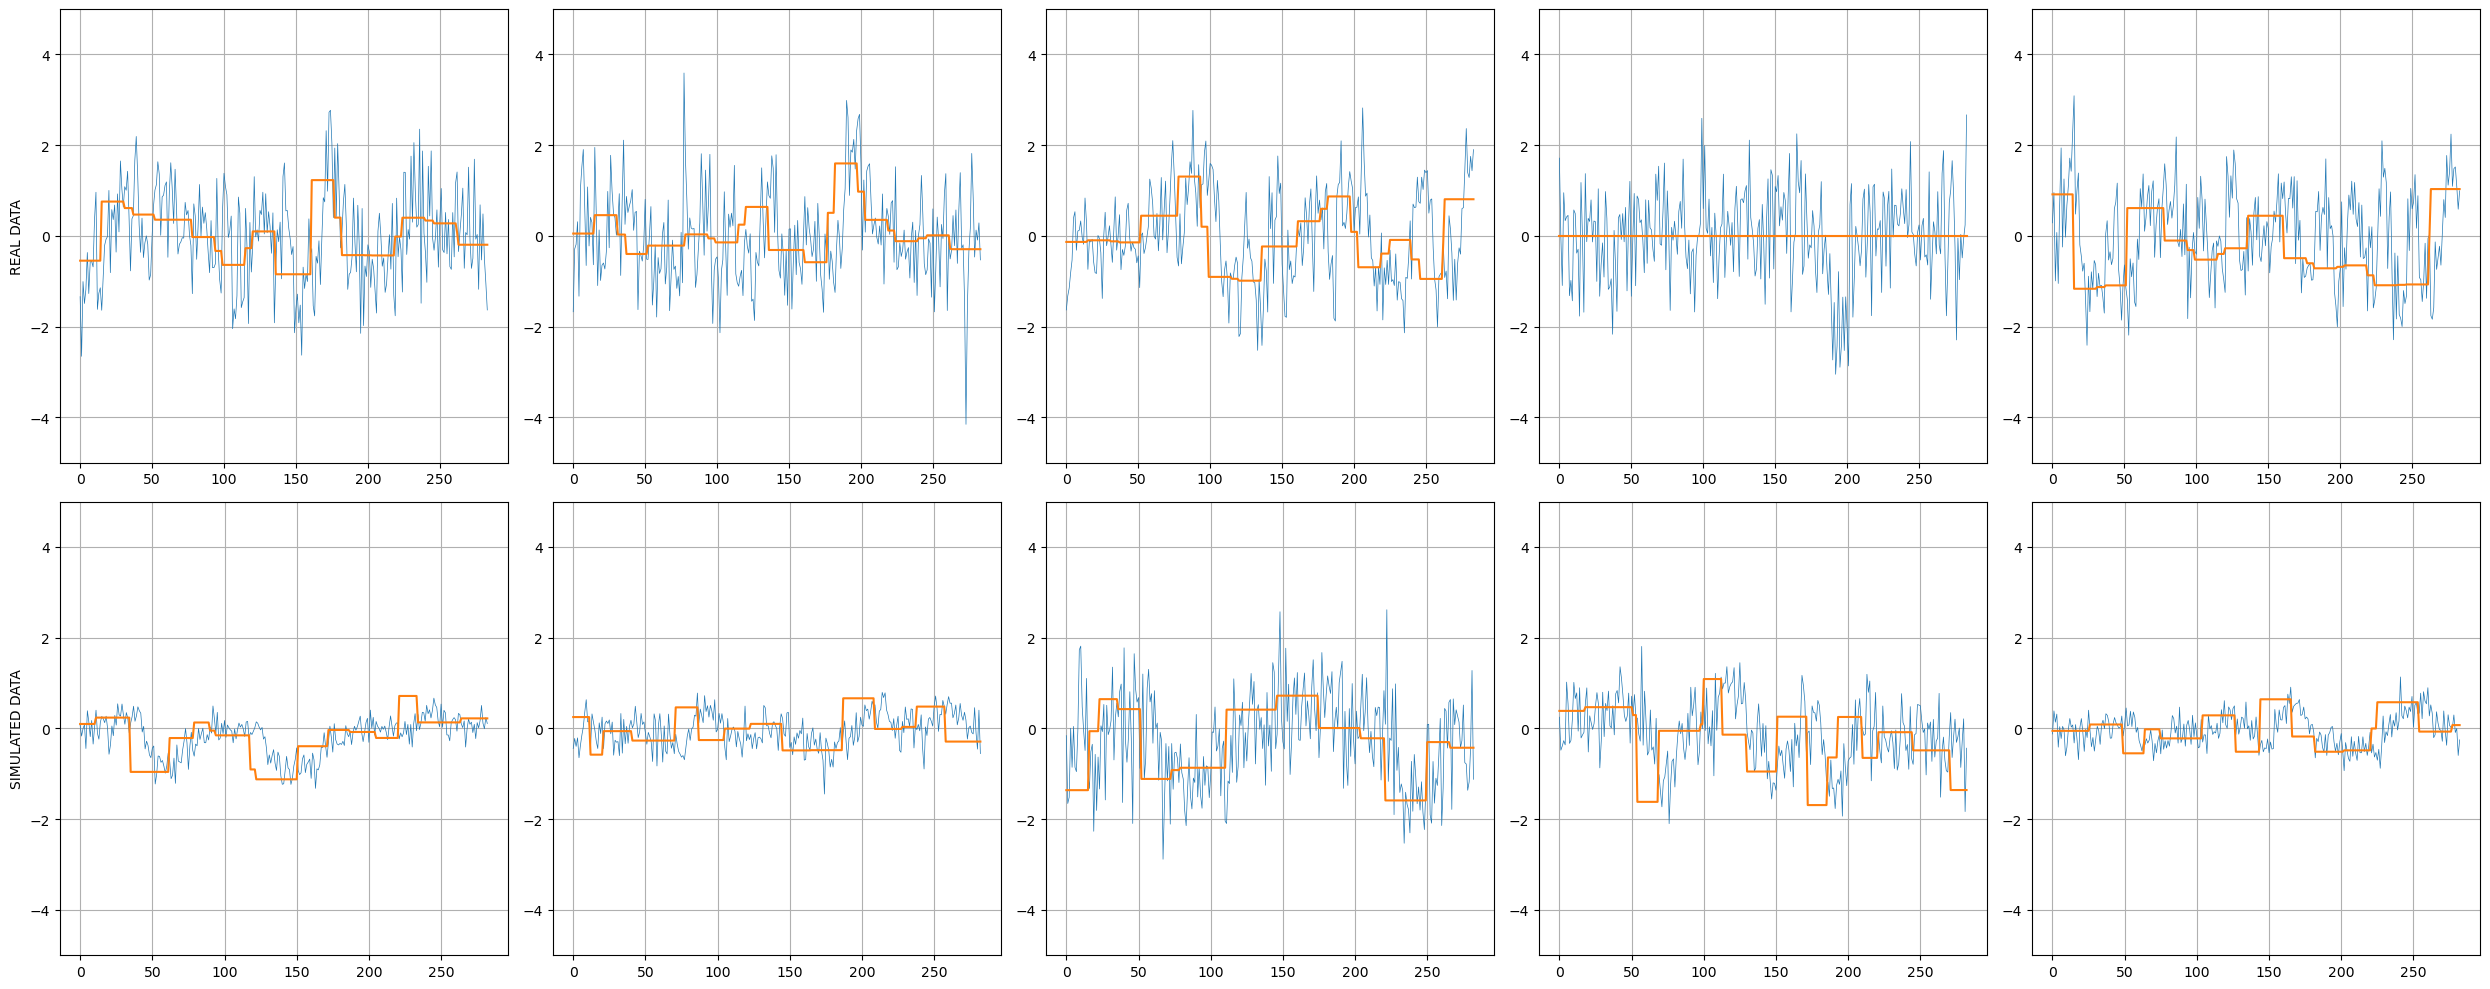

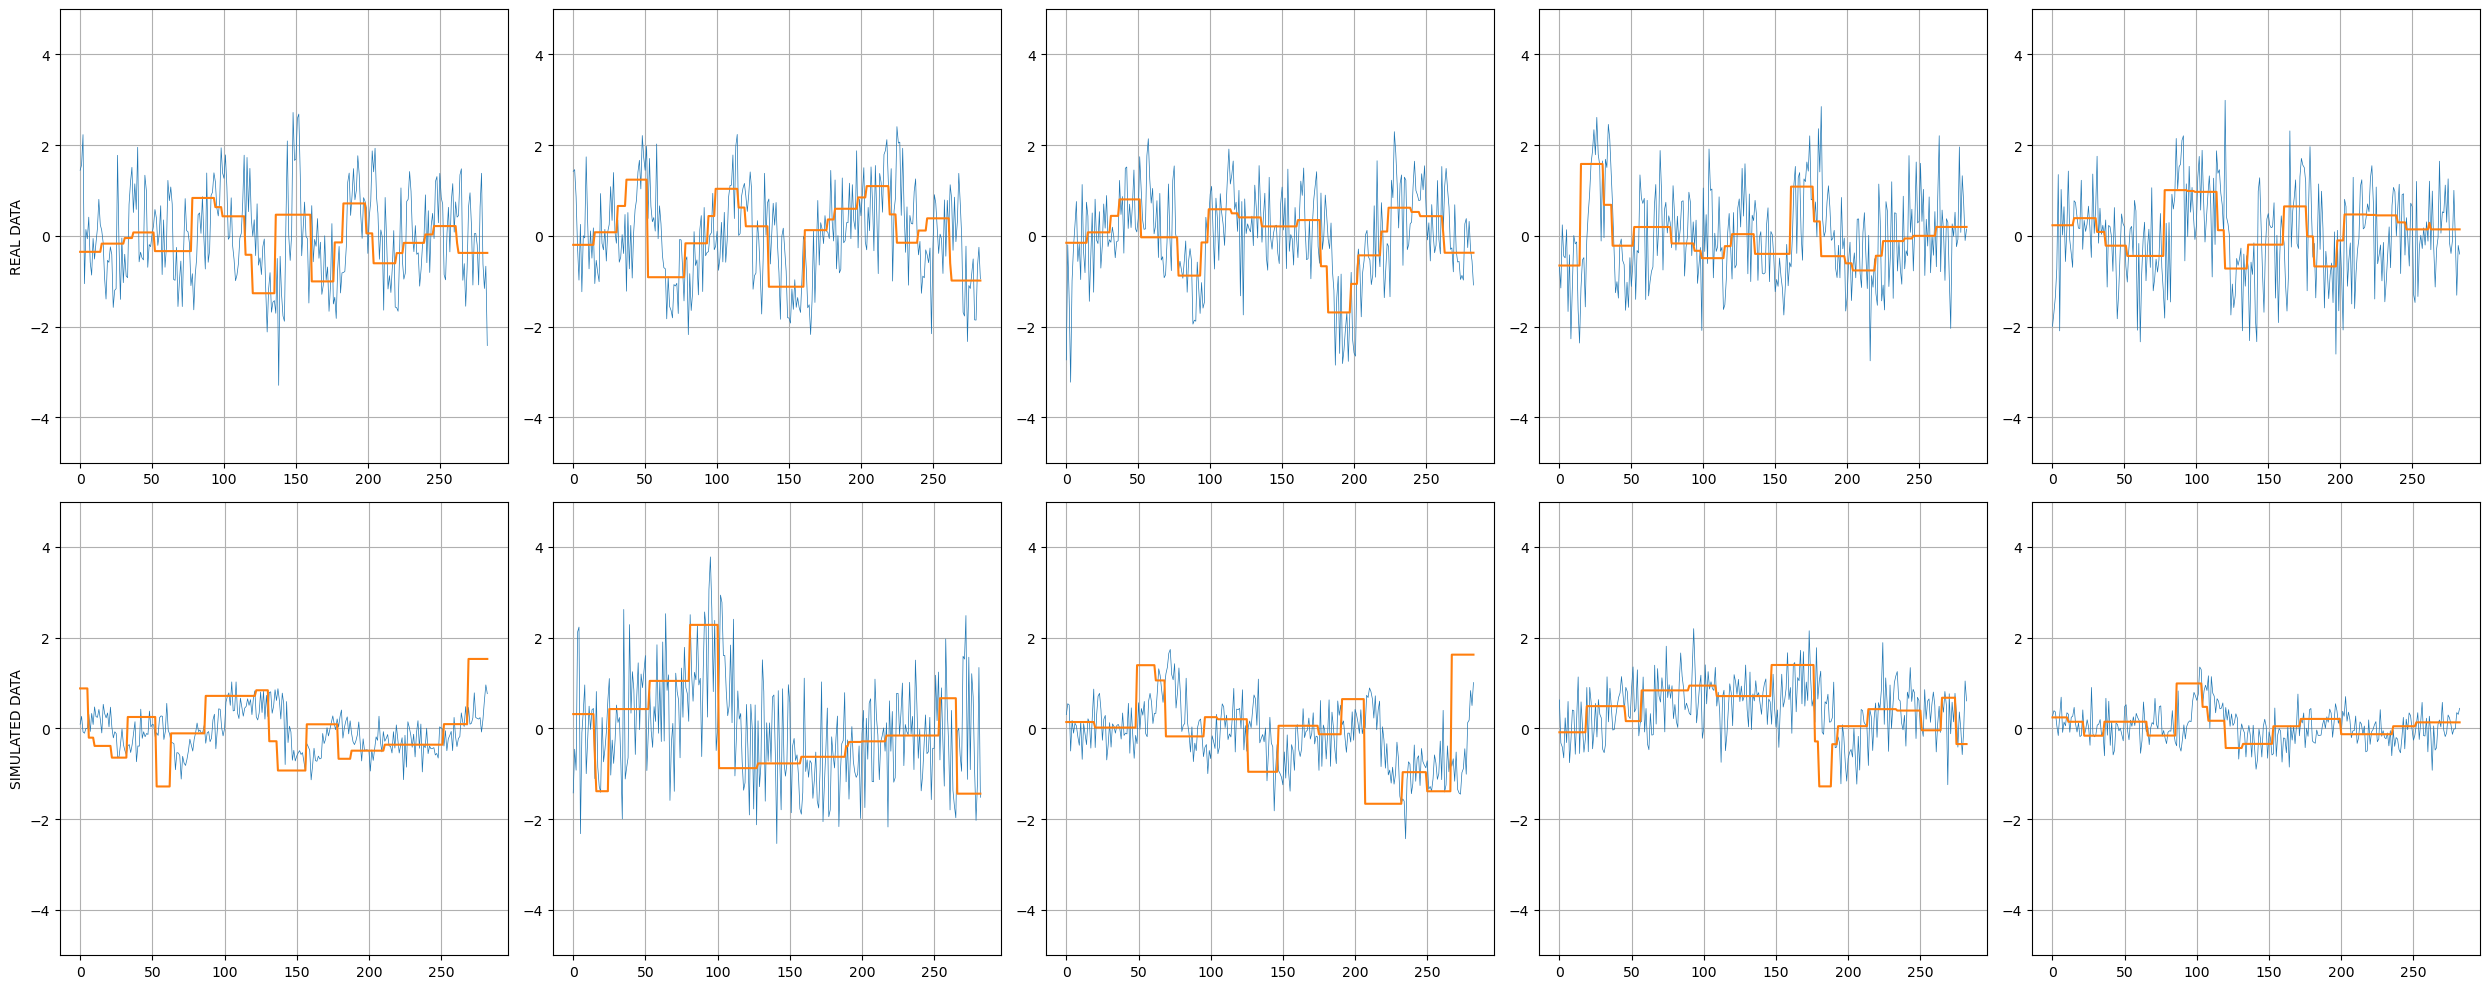

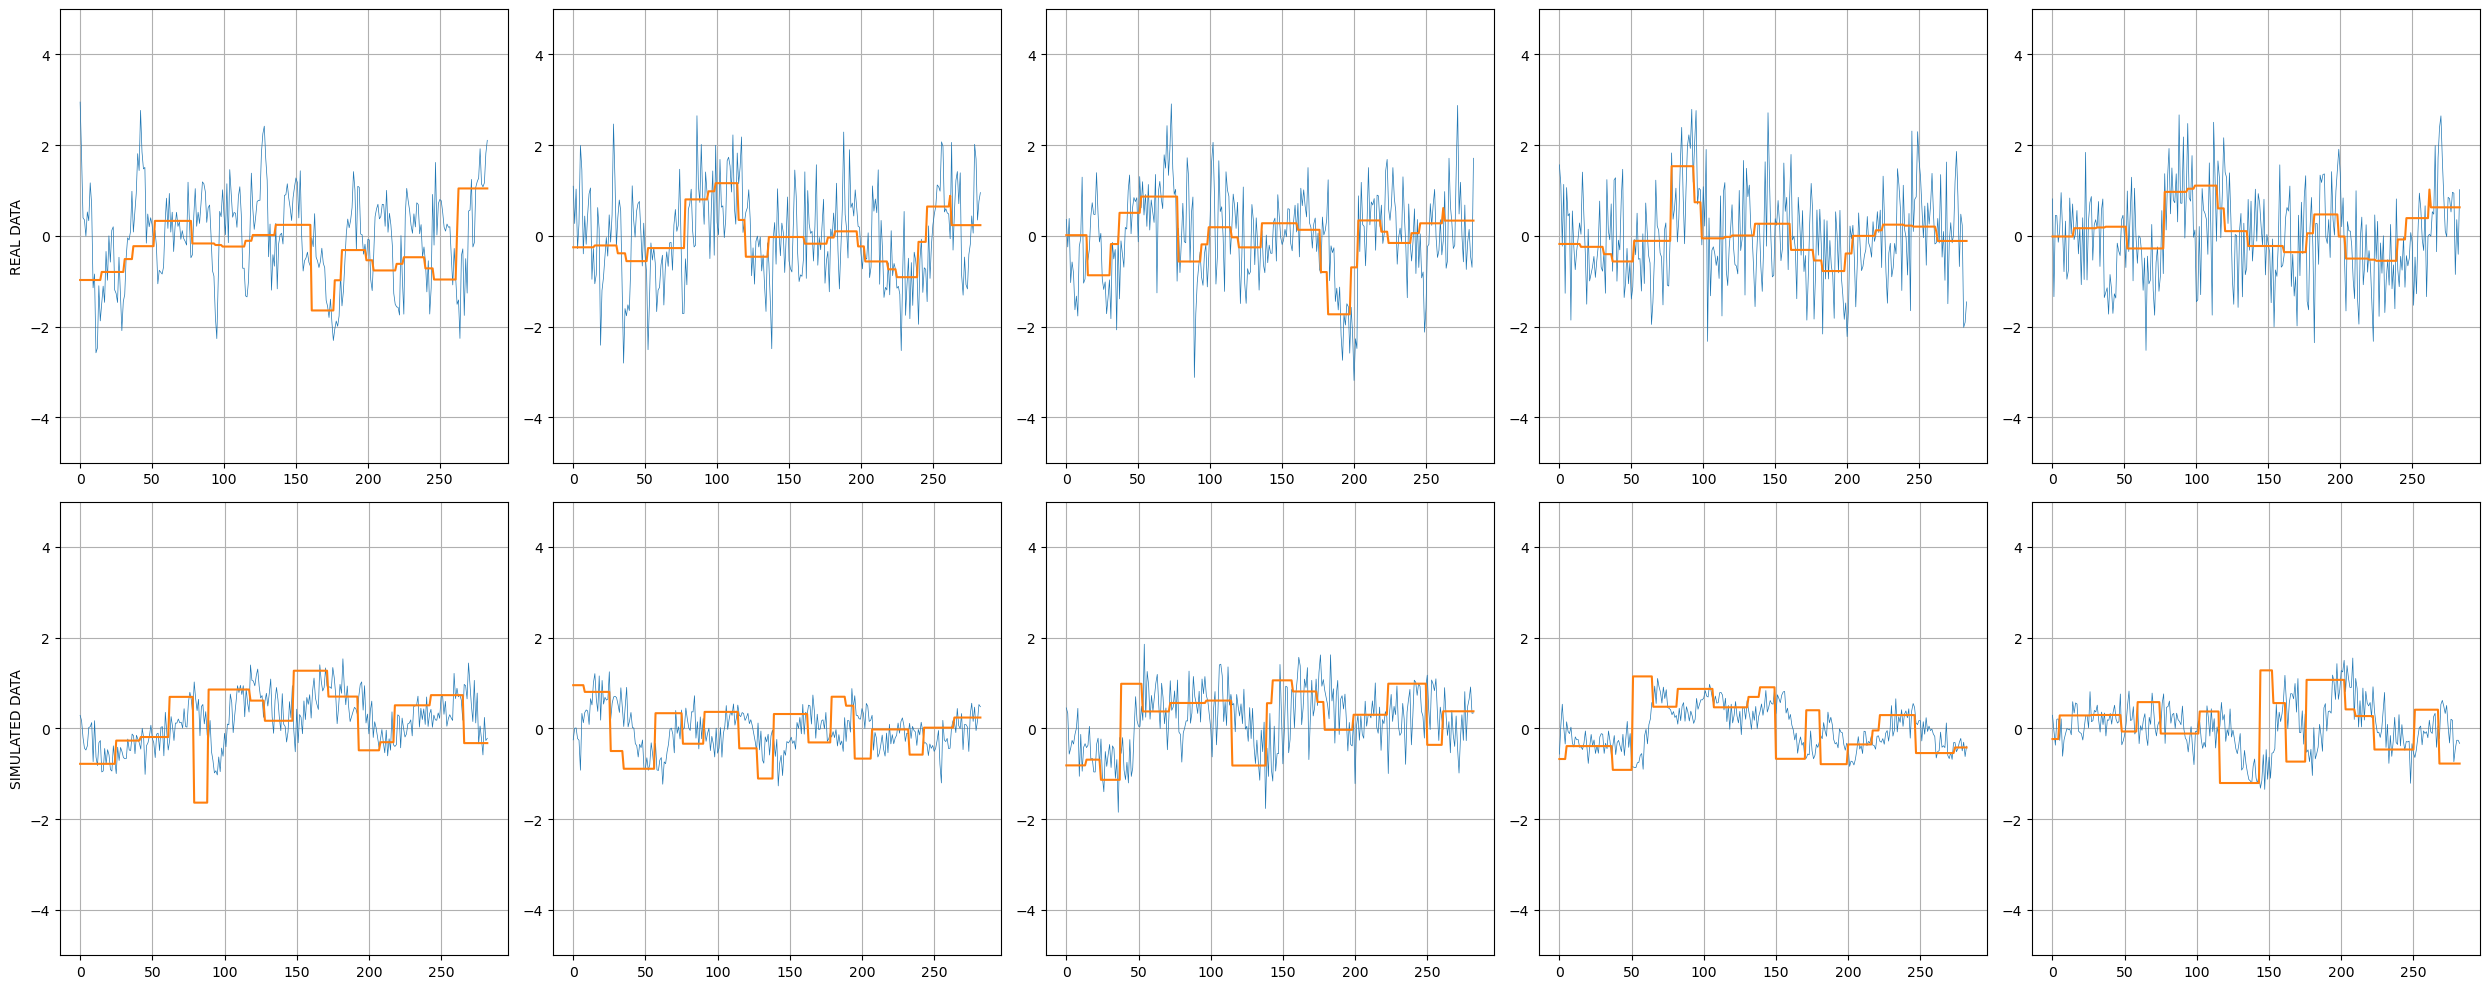

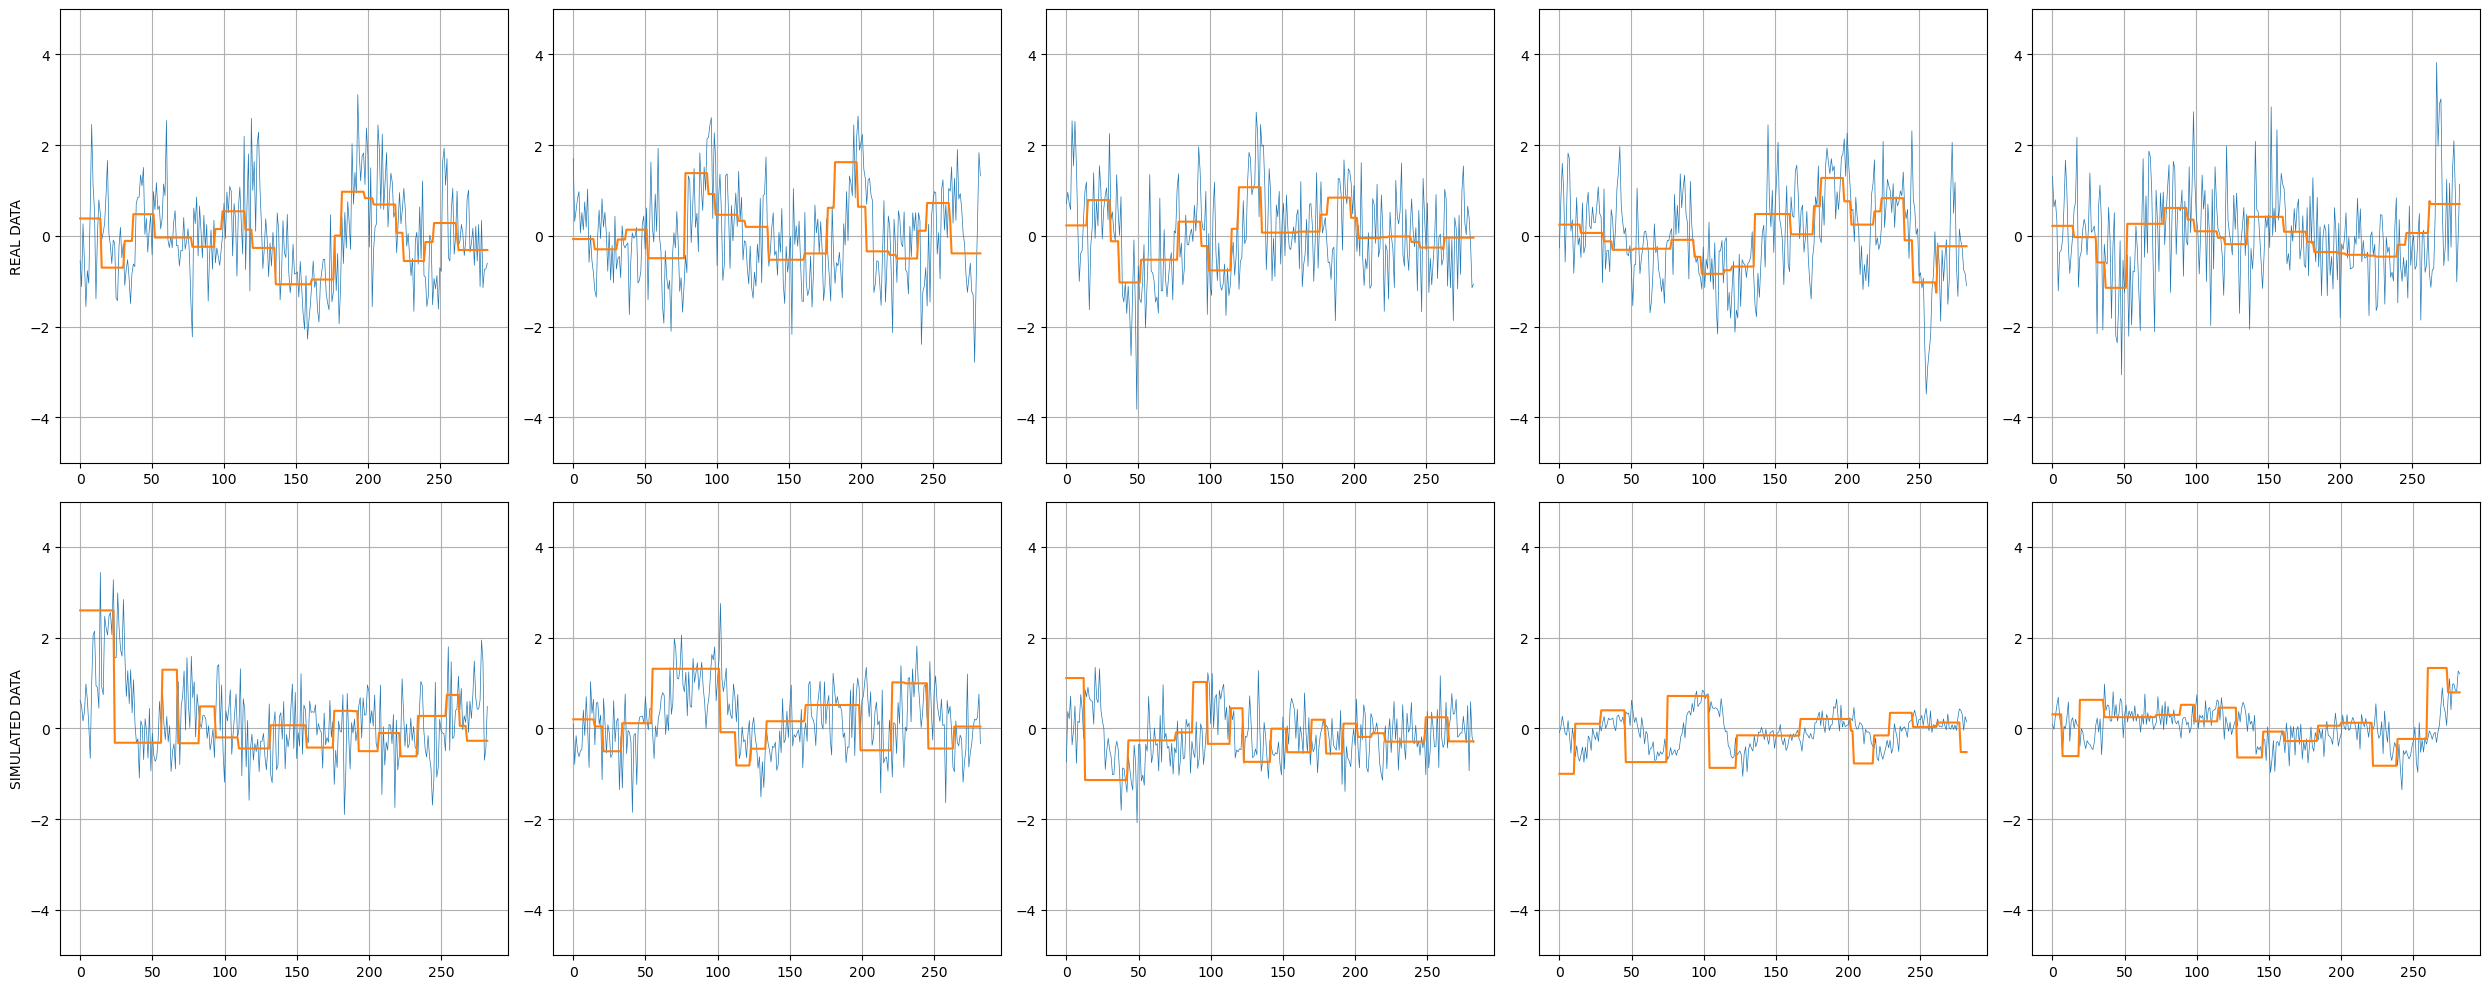

In [23]:
for _ in range(5):  
    f, ax = plt.subplots(2, 5, figsize=(25, 10))
    for i in range(5):
        
        v_real = np.random.randint(0, len(real_test_dataset))
        X_real, y_real = real_test_dataset[v_real][0], real_test_dataset[v_real][1]
        ax[0, i].plot(X_real, label='input', linewidth=0.5)
        ax[0, i].plot(y_real, label='target')
        
        v_sim = np.random.randint(0, len(sim_data_test))
        X_sim, y_sim = sim_data_test[v_sim][0], sim_data_test[v_sim][1]
        ax[1, i].plot(X_sim, label='input', linewidth=0.5)
        ax[1, i].plot(y_sim, label='target')

    for a in ax.flatten(): a.set_ylim([-5, 5]), a.grid()

    ax[0, 0].set_ylabel('REAL DATA')
    ax[1, 0].set_ylabel('SIMULATED DATA')
    f.tight_layout()

# Visualise all regimes

In [28]:
from nilearn.glm.first_level import spm_hrf
from nipy.modalities.fmri.hrf import spm_hrf_compat

dataset_zero = torch.load('datasets/simulated_data_new_100m.pt')['test']
dataset_alice = torch.load('datasets/simulated_data_alice_300m.pt')['test']
dataset_bob = torch.load('datasets/simulated_data_bob_300m.pt')['test']

data_dict = {
    'zero': [dataset_zero, 'spm'],
    'bob': [dataset_bob, 'spm'],
    'alice': [dataset_alice, 'random'],
}

/tmp/ipykernel_461221/2700582567.py:19: DeprecationWarning: The parameter "tr" will be removed in 0.13.0 release of Nilearn. Please use the parameter "t_r" instead.
  hrf = spm_hrf(tr=0.72, oversampling=2, time_length=32.0, onset=0.)
/tmp/ipykernel_461221/2700582567.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


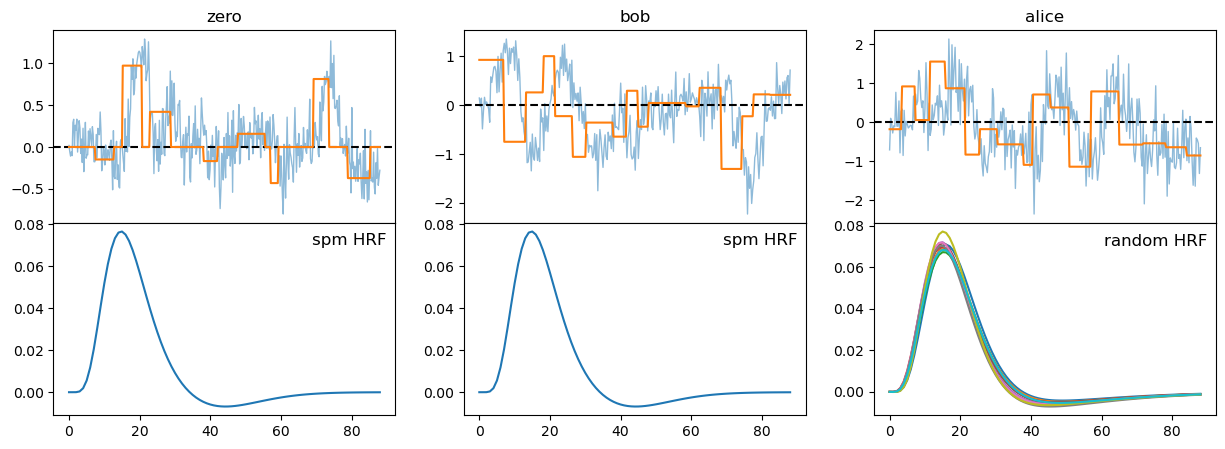

In [44]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))

for a, (key, val) in zip(ax, data_dict.items()):
    v = np.random.randint(0, 10000)
    dataset, hrf_type = val

    pos = a.get_position()
    height = pos.height / 2
    ax_top = f.add_axes([pos.x0, pos.y0 + height, pos.width, height])
    ax_bottom = f.add_axes([pos.x0, pos.y0, pos.width, height])
    f.delaxes(a)

    ax_top.plot(dataset[v][0], alpha=0.5, linewidth=1)
    ax_top.axhline(y=0, linestyle='--', color='k')
    ax_top.plot(dataset[v][1])
    ax_top.set_title(key)

    if hrf_type == 'spm':
        hrf = spm_hrf(tr=0.72, oversampling=2, time_length=32.0, onset=0.)
        ax_bottom.plot(hrf)
    elif hrf_type == 'random':
        t = np.arange(0, 64, .72)
        for _ in range(10):
            hrf = spm_hrf_compat(
                t,
                peak_delay=np.random.uniform(13, 14),
                under_delay=np.random.uniform(30, 31),
                peak_disp=np.random.uniform(2.0, 2.5),
                under_disp=np.random.uniform(9.5, 9.5),
                p_u_ratio=max(1.25, np.random.normal(3, 0.5)),
                normalize=False
            )
            ax_bottom.plot(hrf)
    ax_bottom.text(90, 0.07, hrf_type + ' HRF', ha='right', size=12)

f.tight_layout()